In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np



In [3]:
local_csv = "sales.csv"
df = pd.read_csv(local_csv)

print(df.head())

                         date      sales
0  2022-09-03 17:10:08.079328  55.292157
1  2022-09-04 17:10:08.079328  53.803211
2  2022-09-05 17:10:08.079328  58.141693
3  2022-09-06 17:10:08.079328  64.530899
4  2022-09-07 17:10:08.079328  66.013633


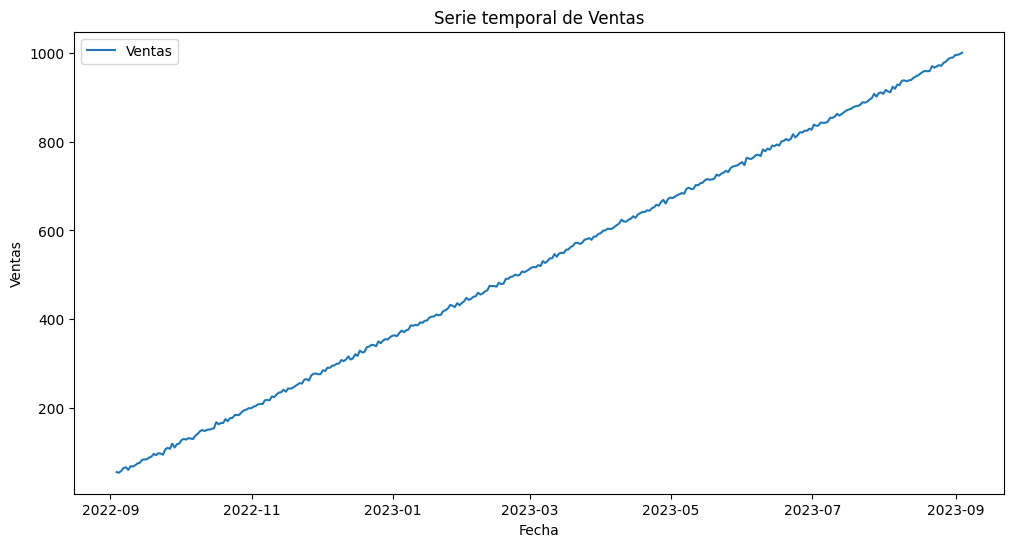

In [9]:
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

ts = df["sales"]

plt.figure(figsize=(12,6))
plt.plot(ts, label="Ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Serie temporal de Ventas")
plt.legend()
plt.show()

In [10]:
result = adfuller(ts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] < 0.05:
    print("La serie es estacionaria")
else:
    print("La serie NO es estacionaria")

ADF Statistic: 0.545414193706381
p-value: 0.9861899815311065
La serie NO es estacionaria


In [13]:
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

c:\Users\sm730\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sm730\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\sm730\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -838.552
Date:                Wed, 24 Sep 2025   AIC                           1683.104
Time:                        11:46:17   BIC                           1694.124
Sample:                    09-03-2022   HQIC                          1687.518
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.002    427.818      0.000       0.995       1.005
ma.L1         -0.9990      0.806     -1.240      0.215      -2.578       0.580
sigma2        18.3647     14.790      1.242      0.2

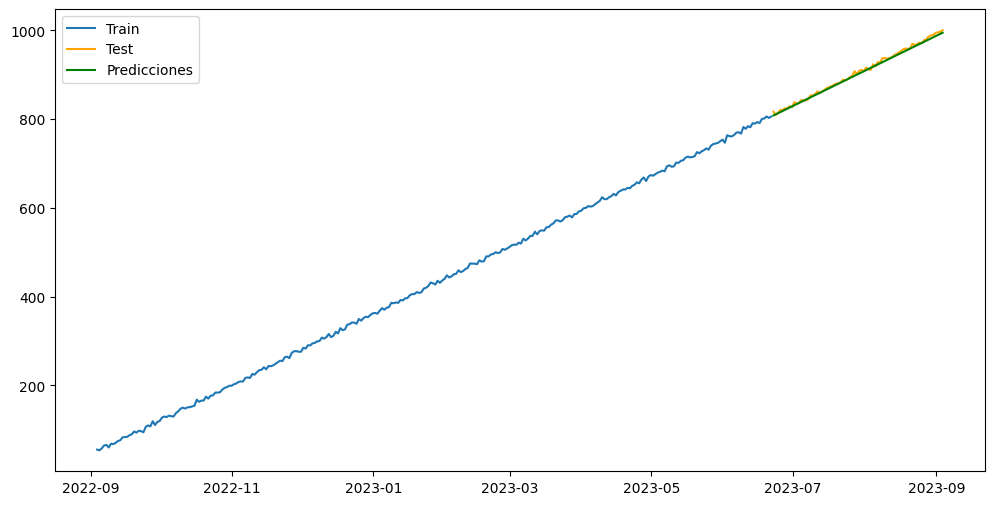

MSE: 16.749917898329002
RMSE: 4.092666355608407
MAE: 3.3060185148643213


In [15]:
pred = model_fit.forecast(steps=len(test))

plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="orange")
plt.plot(test.index, pred, label="Predicciones", color="green")
plt.legend()
plt.show()

mse = mean_squared_error(test, pred)
mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

In [17]:
import joblib
joblib.dump(model_fit, "arima_sales.pkl")
print("Modelo guardado como arima_sales.pkl")

Modelo guardado como arima_sales.pkl
